# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Muhammad Fauzan
- Email: ojanmohmadin1701@gmail.com
- Id Dicoding: muhfouza

## **Business Understanding**

### 1 - Background

Jaya Jaya Institut merupakan salah satu institusi pendidikan tinggi yang telah berdiri sejak tahun 2000 dan telah menghasilkan banyak lulusan dengan reputasi yang baik. Namun, institusi ini menghadapi permasalahan yang cukup serius, yaitu tingginya jumlah mahasiswa yang tidak menyelesaikan pendidikannya atau mengalami dropout.

Tingginya tingkat dropout dapat memberikan dampak negatif bagi institusi, seperti menurunnya reputasi akademik, berkurangnya jumlah lulusan, serta potensi kerugian secara finansial. Oleh karena itu, institusi membutuhkan suatu sistem yang mampu membantu mengidentifikasi mahasiswa yang memiliki risiko tinggi untuk mengalami dropout.

Dengan memanfaatkan data historis mahasiswa, pendekatan data science dapat digunakan untuk menganalisis faktor-faktor yang mempengaruhi dropout serta membangun model machine learning yang mampu memprediksi kemungkinan seorang mahasiswa akan dropout.

### 2 - Problem Statement

Berdasarkan latar belakang tersebut, beberapa permasalahan utama yang ingin diselesaikan dalam proyek ini adalah:
1. Faktor apa saja yang mempengaruhi mahasiswa untuk mengalami dropout di Jaya Jaya Institut?
2. Bagaimana cara memprediksi mahasiswa yang memiliki risiko tinggi untuk mengalami dropout?
3. Bagaimana cara menyajikan informasi terkait performa mahasiswa secara visual agar mudah dipahami oleh pihak institusi?

### 3 - Project Objectives

Tujuan dari proyek ini adalah:
1. Melakukan analisis terhadap data performa mahasiswa untuk memahami pola yang berkaitan dengan dropout.
2. Mengembangkan model machine learning yang dapat memprediksi kemungkinan seorang mahasiswa akan mengalami dropout.
3. Membuat dashboard visualisasi data untuk membantu pihak institusi dalam memonitor performa mahasiswa.
4. Mengembangkan prototype sistem prediksi berbasis machine learning menggunakan Streamlit yang dapat digunakan oleh pihak institusi.

### 4 - Analytical Approach

Pendekatan analisis yang digunakan dalam proyek ini meliputi beberapa tahapan utama dalam data science lifecycle, yaitu:
1. Exploratory Data Analysis (EDA) untuk memahami karakteristik data dan menemukan pola yang berkaitan dengan dropout.
2. Data preprocessing untuk mempersiapkan data agar dapat digunakan dalam proses pemodelan machine learning.
3. Machine learning modeling untuk membangun model prediksi dropout mahasiswa.
4. Model evaluation untuk menilai performa model menggunakan metrik evaluasi yang sesuai.
5. Deployment dengan membuat prototype aplikasi prediksi menggunakan Streamlit.

### 5 - Expected Output

Output yang dihasilkan dari proyek ini meliputi:
1. Analisis data yang menjelaskan faktor-faktor yang mempengaruhi dropout mahasiswa.
2. Model machine learning yang mampu memprediksi kemungkinan mahasiswa mengalami dropout.
3. Dashboard visualisasi data untuk memonitor performa mahasiswa.
4. Prototype sistem prediksi dropout berbasis web menggunakan Streamlit.

## **Persiapan**

### Import Library

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

import joblib

### Data Loading

In [2]:
df = pd.read_csv("data/data_jaya_institut.csv", sep=";")

## **Data Understanding**

### Melihat Struktur Dataset

In [3]:
# 1 - Melihat 5 baris pertama Dataset
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [4]:
# 2 - Melihat Struktur Dataset
df.shape

(4424, 37)

In [5]:
# 3 - Melihat Kolom yang tersedia pada dataset
df.columns

Index(['Marital_status', 'Application_mode', 'Application_order', 'Course',
       'Daytime_evening_attendance', 'Previous_qualification',
       'Previous_qualification_grade', 'Nacionality', 'Mothers_qualification',
       'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation',
       'Admission_grade', 'Displaced', 'Educational_special_needs', 'Debtor',
       'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder',
       'Age_at_enrollment', 'International',
       'Curricular_units_1st_sem_credited',
       'Curricular_units_1st_sem_enrolled',
       'Curricular_units_1st_sem_evaluations',
       'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade',
       'Curricular_units_1st_sem_without_evaluations',
       'Curricular_units_2nd_sem_credited',
       'Curricular_units_2nd_sem_enrolled',
       'Curricular_units_2nd_sem_evaluations',
       'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade',
       'Curricular_units_2nd_sem_wit

In [6]:
# 4 - Melihat Informasi Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [7]:
# 5 - Melihat statistik numerik dataset
df.describe

<bound method NDFrame.describe of       Marital_status  Application_mode  Application_order  Course  \
0                  1                17                  5     171   
1                  1                15                  1    9254   
2                  1                 1                  5    9070   
3                  1                17                  2    9773   
4                  2                39                  1    8014   
...              ...               ...                ...     ...   
4419               1                 1                  6    9773   
4420               1                 1                  2    9773   
4421               1                 1                  1    9500   
4422               1                 1                  1    9147   
4423               1                10                  1    9773   

      Daytime_evening_attendance  Previous_qualification  \
0                              1                       1   
1                

In [8]:
# 6 - Mengecek Missing Values
df.isnull().sum()

Marital_status                                  0
Application_mode                                0
Application_order                               0
Course                                          0
Daytime_evening_attendance                      0
Previous_qualification                          0
Previous_qualification_grade                    0
Nacionality                                     0
Mothers_qualification                           0
Fathers_qualification                           0
Mothers_occupation                              0
Fathers_occupation                              0
Admission_grade                                 0
Displaced                                       0
Educational_special_needs                       0
Debtor                                          0
Tuition_fees_up_to_date                         0
Gender                                          0
Scholarship_holder                              0
Age_at_enrollment                               0


In [9]:
# 7 - Melihat Distribusi Target Variable
df["Status"].value_counts()

Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

### Eksploratory Data Analysis (EDA)

#### 1 - Distribusi Status Akademik Mahasiswa

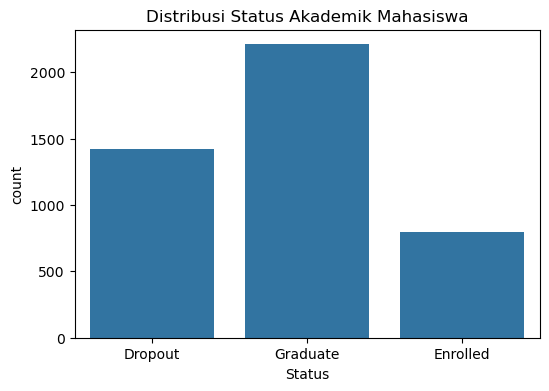

In [10]:
# 1 - Visualisasi Distribusi Status Akademik Mahasiswa
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Status")
plt.title("Distribusi Status Akademik Mahasiswa")
plt.show()

**Insight**

Visualisasi ini menunjukkan distribusi umur mahasiswa saat melakukan pendaftaran. Analisis ini dapat membantu memahami karakteristik usia mahasiswa serta melihat apakah terdapat pola tertentu yang berkaitan dengan risiko dropout.

#### 2 - Rata-rata usia Mahasiswa saat Pendaftaran Berdasarkan Status Akademik

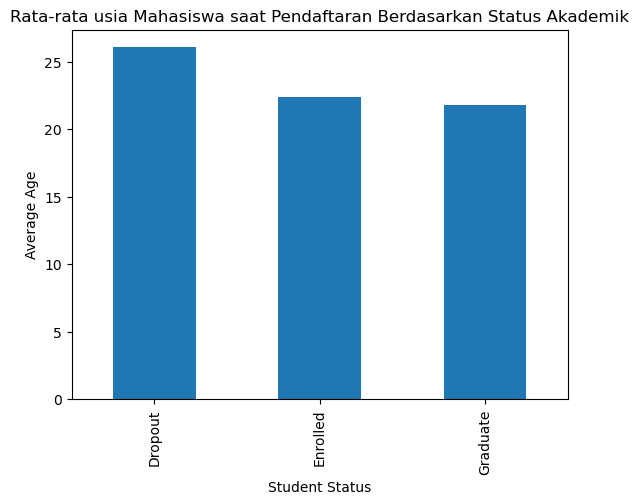

In [11]:
# 2.1 - Visualisasi Rata-rata usia Mahasiswa saat Pendaftaran Berdasarkan Status Akademik
age_status = df.groupby("Status")["Age_at_enrollment"].mean()

age_status.plot(kind="bar")

plt.title("Rata-rata usia Mahasiswa saat Pendaftaran Berdasarkan Status Akademik")
plt.xlabel("Student Status")
plt.ylabel("Average Age")

plt.show()

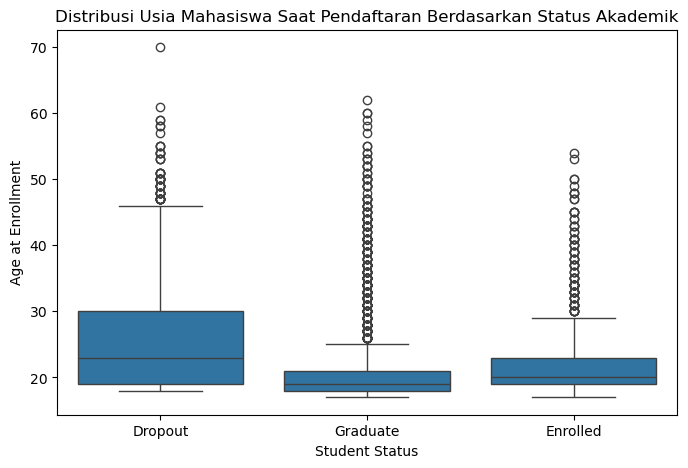

In [12]:
# 2.2 - Visualisasi Distribusi Usia Mahasiswa Saat Pendaftaran Berdasarkan Status Akademik
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Status",
    y="Age_at_enrollment"
)

plt.title("Distribusi Usia Mahasiswa Saat Pendaftaran Berdasarkan Status Akademik")
plt.xlabel("Student Status")
plt.ylabel("Age at Enrollment")

plt.show()

**Insight**

Analisis ini bertujuan untuk melihat hubungan antara kepemilikan beasiswa dengan status mahasiswa. Hasil visualisasi dapat memberikan indikasi apakah mahasiswa yang menerima beasiswa memiliki kecenderungan lebih rendah untuk mengalami dropout dibandingkan mahasiswa yang tidak menerima beasiswa.

#### 3 - Scholarship vs Status

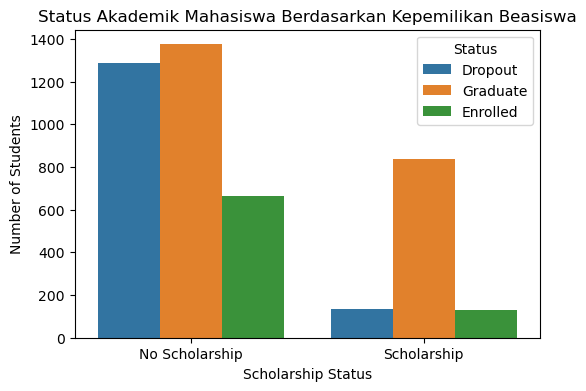

In [13]:
# 3 - Visualisasi Status Akademik Mahasiswa Berdasarkan Kepemilikan Beasiswa
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x="Scholarship_holder", hue="Status")

ax.set_xticklabels(["No Scholarship", "Scholarship"])

plt.title("Status Akademik Mahasiswa Berdasarkan Kepemilikan Beasiswa")
plt.xlabel("Scholarship Status")
plt.ylabel("Number of Students")

plt.show()

**Insight**

Berdasarkan visualisasi hubungan antara status beasiswa dan status mahasiswa, terlihat bahwa mahasiswa yang tidak menerima beasiswa memiliki jumlah dropout yang lebih tinggi dibandingkan mahasiswa yang menerima beasiswa. Hal ini menunjukkan bahwa faktor finansial atau dukungan akademik yang terkait dengan beasiswa dapat berperan dalam meningkatkan keberhasilan studi mahasiswa.

#### 4 - Admission Grade vs Status

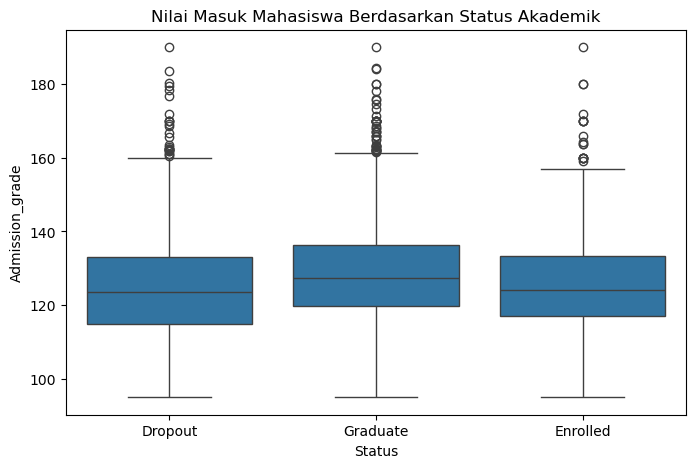

In [14]:
# 4 - Visualisasi Nilai Masuk Mahasiswa Berdasarkan Status Akademik
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Status", y="Admission_grade")
plt.title("Nilai Masuk Mahasiswa Berdasarkan Status Akademik")
plt.show()

**Insight**

Analisis ini bertujuan untuk melihat hubungan antara jumlah mata kuliah yang berhasil diselesaikan pada semester pertama dengan status mahasiswa. Performa akademik pada semester awal sering kali menjadi indikator penting dalam memprediksi kemungkinan mahasiswa mengalami dropout.

#### 5 - Mata Kuliah Lulus Semester 1

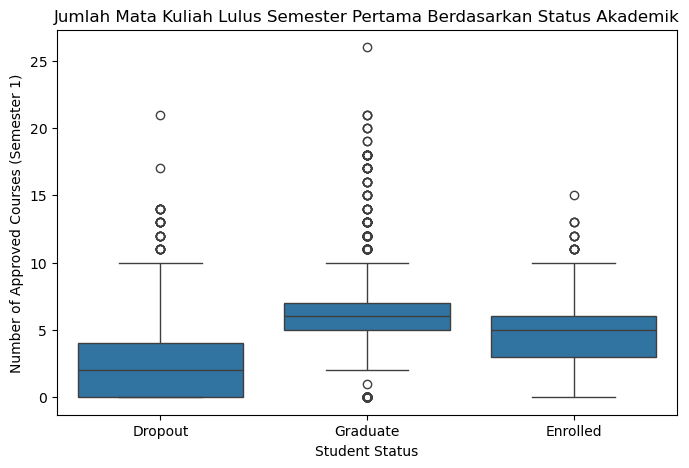

In [15]:
# 5.1 - Visualisasi Jumlah Mata Kuliah Lulus Semester Pertama Berdasarkan Status Akademik
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Status",
    y="Curricular_units_1st_sem_approved"
)

plt.title("Jumlah Mata Kuliah Lulus Semester Pertama Berdasarkan Status Akademik")
plt.xlabel("Student Status")
plt.ylabel("Number of Approved Courses (Semester 1)")

plt.show()

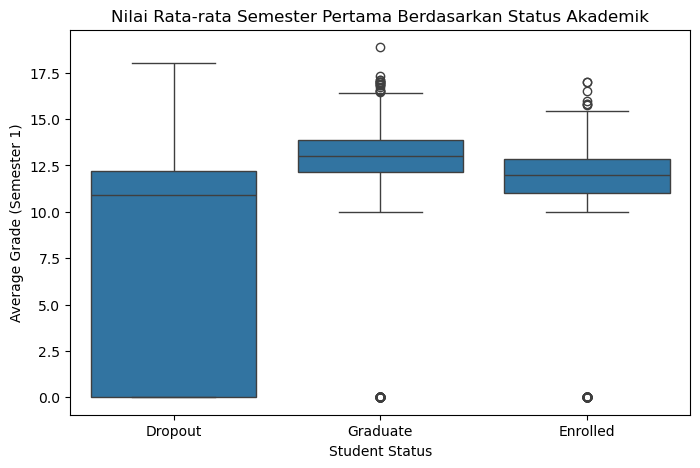

In [16]:
# 5.2 - Visualisasi Nilai Rata-rata Semester Pertama Berdasarkan Status Akademik
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Status",
    y="Curricular_units_1st_sem_grade"
)

plt.title("Nilai Rata-rata Semester Pertama Berdasarkan Status Akademik")
plt.xlabel("Student Status")
plt.ylabel("Average Grade (Semester 1)")

plt.show()

**Insight**

Berdasarkan visualisasi performa akademik semester pertama, terlihat bahwa mahasiswa yang memiliki jumlah mata kuliah yang disetujui serta nilai rata-rata yang lebih tinggi cenderung berhasil menyelesaikan studinya. Sebaliknya, mahasiswa yang memiliki performa akademik rendah pada semester pertama menunjukkan kecenderungan lebih tinggi untuk mengalami dropout. Hal ini menunjukkan bahwa performa akademik pada semester awal dapat menjadi indikator penting dalam mendeteksi risiko dropout mahasiswa.

#### 6 - Korelasi Antar Fitur

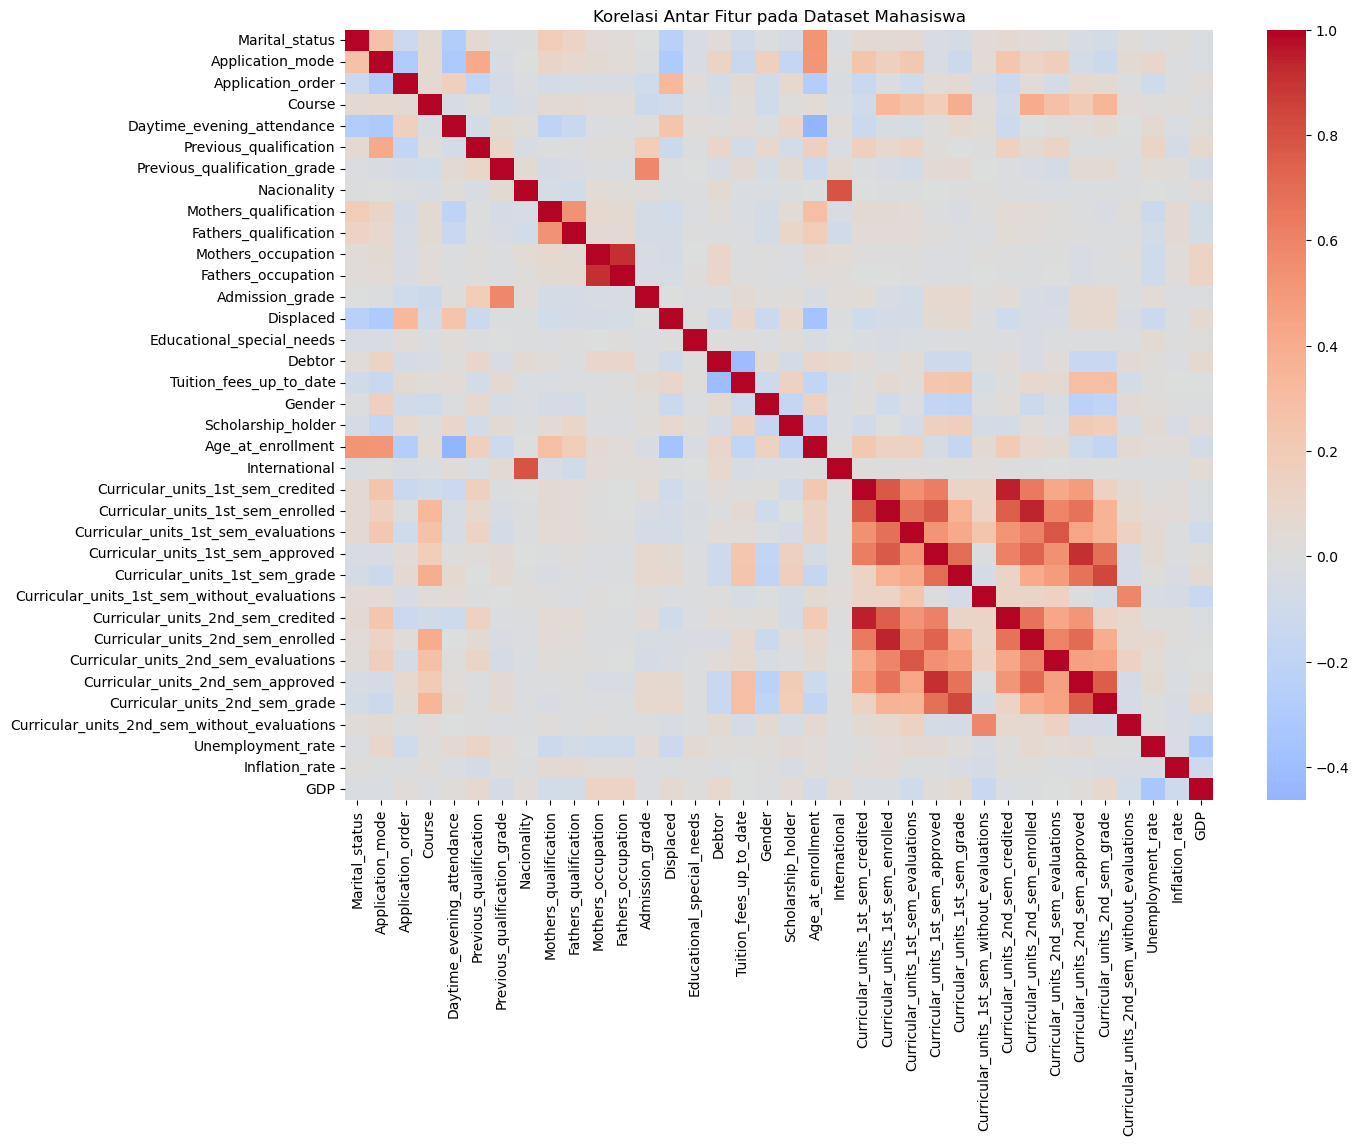

In [17]:
# 6 - Visualisasi Korelasi Antar Fitur pada Dataset Mahasiswa
numeric_df = df.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(14,10))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", center=0)
plt.title("Korelasi Antar Fitur pada Dataset Mahasiswa")
plt.show()

**Insight**

Heatmap korelasi digunakan untuk melihat hubungan antar fitur numerik dalam dataset. Dari visualisasi ini dapat diamati bahwa beberapa fitur akademik seperti jumlah mata kuliah yang disetujui dan nilai semester memiliki korelasi yang cukup kuat. Hal ini menunjukkan bahwa performa akademik mahasiswa berpotensi menjadi faktor penting dalam menentukan status akademik mahasiswa.

## **Insight Summary**

Berdasarkan hasil exploratory data analysis (EDA), ditemukan beberapa pola penting
yang berkaitan dengan status akademik mahasiswa.

Pertama, performa akademik pada semester pertama memiliki hubungan yang kuat
dengan kemungkinan mahasiswa menyelesaikan studi. Mahasiswa yang memiliki jumlah
mata kuliah lulus lebih banyak pada semester pertama cenderung memiliki
kemungkinan lebih tinggi untuk lulus.

Kedua, nilai masuk mahasiswa menunjukkan perbedaan antara mahasiswa yang
mengalami dropout dan mahasiswa yang berhasil lulus, yang menunjukkan bahwa
kemampuan akademik awal dapat mempengaruhi keberhasilan studi.

Ketiga, kepemilikan beasiswa juga menunjukkan hubungan dengan status akademik
mahasiswa. Mahasiswa yang menerima beasiswa cenderung memiliki tingkat
kelulusan yang lebih tinggi dibandingkan mahasiswa tanpa beasiswa.

Berdasarkan temuan tersebut, fitur-fitur yang berkaitan dengan performa akademik,
nilai masuk, serta faktor demografis digunakan sebagai variabel penting dalam
membangun model prediksi dropout mahasiswa.

## **Data Preparation / Preprocessing**

In [18]:
# 1 - Transformasi Target Variable
df["Target"] = df["Status"].apply(lambda x: 1 if x == "Dropout" else 0)

# Cek Hasil Transformasi
df["Target"].value_counts()

Target
0    3003
1    1421
Name: count, dtype: int64

In [19]:
# 2 - Memisahkan Feature dan Target
selected_features = [
    "Age_at_enrollment",
    "Admission_grade",
    "Curricular_units_1st_sem_approved",
    "Curricular_units_2nd_sem_approved",
    "Scholarship_holder",
    "Gender"
]

X = df[selected_features]
y = df["Target"]

In [20]:
# 3 - Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Cek ukuran dataset
print(X_train.shape)
print(X_test.shape)

(3539, 6)
(885, 6)


## **Modeling**

In [21]:
# 1 - Training Model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [22]:
# 2 - Melakukan Prediksi
y_pred = rf_model.predict(X_test)

## **Evaluation**

In [23]:
# 1 - Evaluasi Model
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.90      0.85       569
           1       0.77      0.63      0.69       316

    accuracy                           0.80       885
   macro avg       0.79      0.76      0.77       885
weighted avg       0.80      0.80      0.79       885



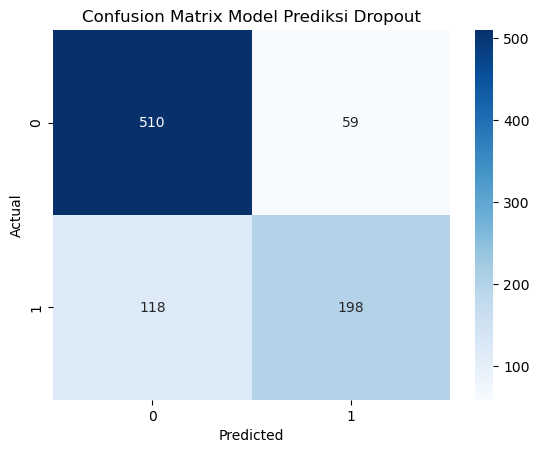

In [24]:
# 2 - Confusion Matrix Model Prediksi Dropout
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix Model Prediksi Dropout")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

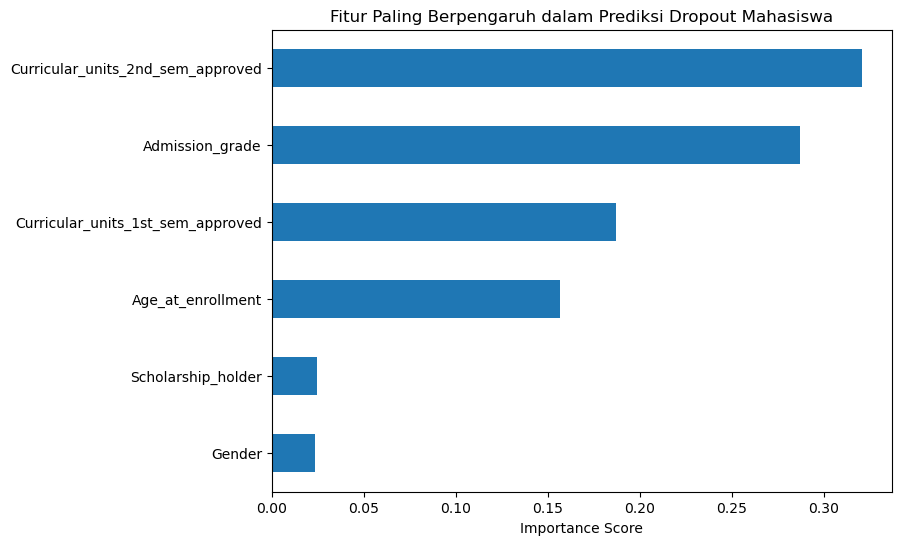

In [28]:
# 3 - Feature Importance - Fitur Paling Berpengaruh dalam Prediksi Dropout Mahasiswa
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# Visualisasi
plt.figure(figsize=(8,6))

feature_importance.head(10).plot(kind="barh")

plt.title("Fitur Paling Berpengaruh dalam Prediksi Dropout Mahasiswa")
plt.xlabel("Importance Score")

plt.gca().invert_yaxis()

plt.show()

### **Insight**

Berdasarkan analisis feature importance dari model Random Forest, terlihat bahwa fitur-fitur yang berkaitan dengan performa akademik pada semester pertama dan kedua memiliki pengaruh paling besar dalam memprediksi risiko dropout mahasiswa. Hal ini menunjukkan bahwa performa akademik pada tahap awal perkuliahan merupakan indikator penting dalam menentukan keberhasilan studi mahasiswa.

---

# **Model Deployment**

In [26]:
joblib.dump(rf_model, "model/model_dropout.pkl")

['model/model_dropout.pkl']

----